# This is Regression (with OLS), NOT Classification

We find the best line represented by Y = theta * X + theta0; where theta could be a vector of any length representing the dimension of X, and theta should be a scalar.

Here, there will be different loss function, but no such loss function which was there in classification function, such as sigmoid, sign, etc. based on which the cost was calculated.

The data given  will have to fit a line or a hyperplane to predict the trend. No featurization of data itself. Just data and a regression element that fits that data.

Here, objective function: LOSS FUNCTION: J(theta, theta0) = squared error = (theta*X + theta0 - Y)^2 = A SQUARE OF (SINGLE GUESSED VALUE - ACTUAL VALUE) FOR A GIVEN DATA POINT 'X', even if 'X' is in multi-dimension.

Using augumented form, J(theta) = (theta*X - Y)^2   where this theta has prepended theta0 with original theta. Also, every X's feature point has prepended '1' as feature component increasing the dimension of feature component by 1, making X of dimension (m, n+1), where m are feature points and n+1 is dimension of each feature point.

Hence, COST: MRSS: Mean of Residual Sum of Squares = (1/m) * SUMMATION(J(theta))

In matrix form: (dividing by m because we are taking out an average of cost of all the points. This 1/m is getting passed on to the gradient also. 1/m should just be treated as a SCALAR)
#### J(theta) = (1/m) * (W * theta - T).transpose * (W * theta - T)

We know, that cost is minimized at place where partial derivative of cost function w.r.t theta and theta0 will be 0. Now here we are not considering gradient descent because the cost function is sureshot a quadratic convex and differentiable, while in classification models the hyperplane can be of higher degree, making it prone to having more than 1 local minimas (recall featurization where we increase the dimension of input). So, differentiating cost wrt each thetas and theta0 will be costlier in higher degree functions, if comapred with quadratic functions.

Now, here, we partially differentiate cost w.r.t. each theta component (including all components of original theta and theta0), and the equate each of them with 0 to get that corresponding theta component (You know the drill already). This technically is called as taking gradient of cost (J) function which gives a vector of dau_J/dau_theta_i components.

How to intutionally derive gradient of cost J ? Well, (W * theta - T).transpose * (W * theta - T) is just a L-2 norm of (W * theta - T), i.e., sum of square of individual components. Consider this a single term represented as P^2. So, derivative of P^2 w.r.t. theta will be 2 * P * d_P/d_theta.

Hence, 
#### gradient(J(theta)) = 2 * (1/m) * W.transpose * (W * theta - T)
   ===   where we just want a vector of thetas of dimension (n+1, 1) by multiplying a scalar, a matrix of dimension (n+1, m), and a vector of dimension (m, 1).

Now that we have partial derivates of J w.r.t each theta component: 

#### W.transpose * (W * theta - T) = 0

#### W.transpose * W * theta - W.transpose * T = 0

#### W.transpose * W * theta = W.transpose * T

#### INV(W.transpose * W) * W.transpose * W * theta = INV(W.transpose * W) * W.transpose * T

#### theta* = INV(W.transpose * W) * W.transpose * T

### BLOCKERS:
1. (W.transpose * W) is not invertible, i.e., feature components are dependedent.
2. Computational time is too large for finding RHS of theta, if INVERSE(W.transpose * W) exists.
3. Overfitting and noise capturing.

### SOLUTION:
1. Use Regularizer with the regression Cost Term.
#### J_ridge(theta) = (1/m) * (W * theta - T).transpose * (W * theta - T) + lambda * ||theta_tild||
#### gradient(J_ridge(theta)) = 2 * (1/m) * W.transpose * (W * theta - T) + 2 * lambda * theta_tild
#### theta_ridge* = INV(W.transpose * W + m * lambda * I) * W.transpose * T

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [19]:
# Set random seet for reproducibility
np.random.seed(42)
plt.style.use('ggplot')

In [ ]:
# Generate a simple linear dataset
n_samples = 30
X_input = np.linspace(0, 10, n_samples)
y = 2 * X_input + 1 + np.random.randn(n_samples)    # True slope is 2, intercept is 1, some noise

In [21]:
# Add three impactful outliers
X_input = np.append(X_input, [15, 18, 20]) # Farther on the x-axis
y = np.append(y, [80, 90, 100])      # Much higher y-values

In [22]:
# Add the intercept terms
X =np.hstack([np.ones((n_samples + 3, 1)), X_input.reshape(-1, 1)])

In [23]:
# Compute the OLS and Ridge regression coefficients as solutions to the normal equations
beta_OLS = np.linalg.inv(X.T @ X) @ X.T @ y
lambda_ridge = 1000 # A stronger lambda to emphasis Ridge's dampening effect
I = np.eye(X.shape[1])
beta_Ridge = np.linalg.inv(X.T @ X + lambda_ridge * I) @ X.T @ y

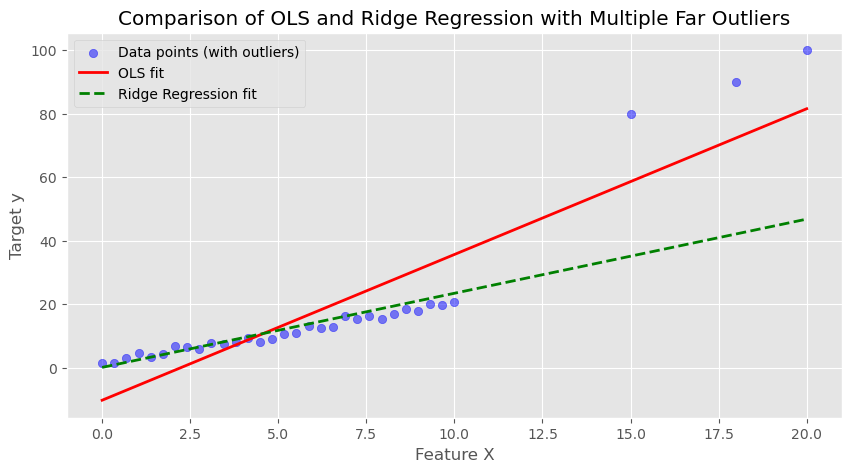

In [24]:
# Prepare to plot the results
plt.figure(figsize=(10, 5))
plt.scatter(X_input, y, color='blue', alpha=0.5, label='Data points (with outliers)')
# Plot the OLS fit
x_range = np.linspace(np.min(X_input), np.max(X_input), 100)
y_OLS = beta_OLS[0] + beta_OLS[1] * x_range
plt.plot(x_range, y_OLS, color='red', linestyle='-', label='OLS fit', linewidth=2)
# Plot the ridge regression fit
y_Ridge = beta_Ridge[0] + beta_Ridge[1] * x_range
plt.plot(x_range, y_Ridge, color='green', linestyle='--', label='Ridge Regression fit', linewidth=2)
plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.title('Comparison of OLS and Ridge Regression with Multiple Far Outliers')
plt.legend(loc='best')

In [25]:
# Slope of the two models - OLS and Ridge
beta_OLS[1], beta_Ridge[1]

(np.float64(4.58942769863536), np.float64(2.3347277015540007))